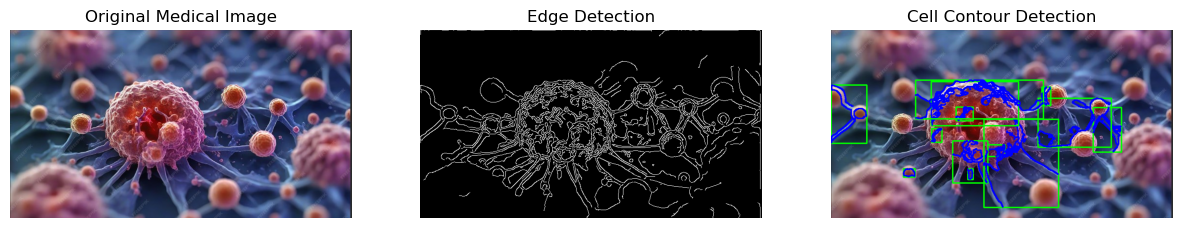

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load medical cell image
image = cv2.imread("cells.jpg")
output = image.copy()

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur to reduce noise
blur = cv2.GaussianBlur(gray,(5,5),0)

# Edge detection
edges = cv2.Canny(blur,40,120)

# Find contours
contours,_ = cv2.findContours(edges,
                              cv2.RETR_EXTERNAL,
                              cv2.CHAIN_APPROX_SIMPLE)

# Draw contours and bounding boxes
for contour in contours:

    area = cv2.contourArea(contour)

    if area > 100:

        x,y,w,h = cv2.boundingRect(contour)

        cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),2)

        cv2.drawContours(output,[contour],-1,(255,0,0),2)


# Show results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Medical Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edges,cmap="gray")
plt.title("Edge Detection")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Cell Contour Detection")
plt.axis("off")

plt.show()